In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy
import glob


# Import and plot data (with FCN)

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD', 'dX', 'sigma_dX', 'dY', 'sigma_dY']
    cols_widths = [(0,11),(12,22),(23,33),(34,44),(45,55)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [3]:
df = process_data('nut_ivs.dat')

In [4]:
len(df)

3979

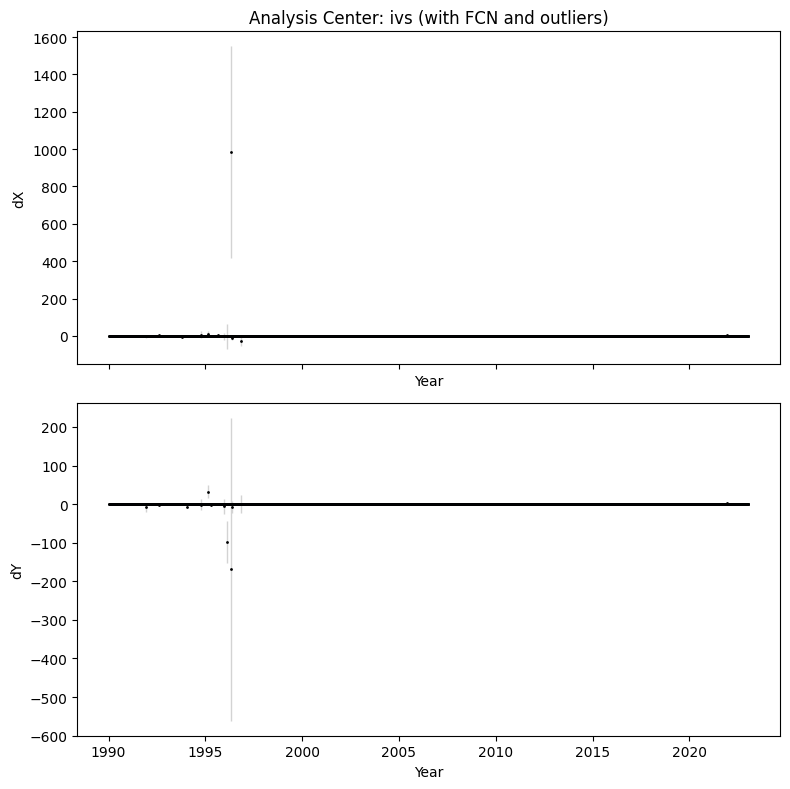

In [5]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dX'], yerr=df['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: ivs (with FCN and outliers)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dY'], yerr=df['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

In [6]:
def remove_outliers(df,datatype):
    if datatype == 'dX':
        df_sel = df[['MJD','dX','sigma_dX']].copy()
        datas = 'dX'
        datas_e = 'sigma_dX'
    elif datatype == 'dY':
        df_sel = df[['MJD','dY','sigma_dY']].copy()
        datas = 'dY'
        datas_e = 'sigma_dY'
    else:
        print('Please choose dX/dY data')

    for index, row in df_sel.iterrows():
        data_values = df_sel[(df_sel['MJD'] >= (row['MJD'] - 365)) & (df_sel['MJD'] <= (row['MJD'] + 365))]
        wd = 1/data_values[datas_e].values**2
        mean = np.average(data_values[datas],weights=wd)
        std = np.sqrt(allanself.wvar(data_values[datas].values,wd))
        if abs(row[datas] - mean) > 6*std:
            df_sel.drop(index, inplace = True)
    return df_sel

In [7]:
df_dX = remove_outliers(df,'dX')

In [8]:
len(df_dX)

3961

In [9]:
df_dY = remove_outliers(df,'dY')
len(df_dY)

3967

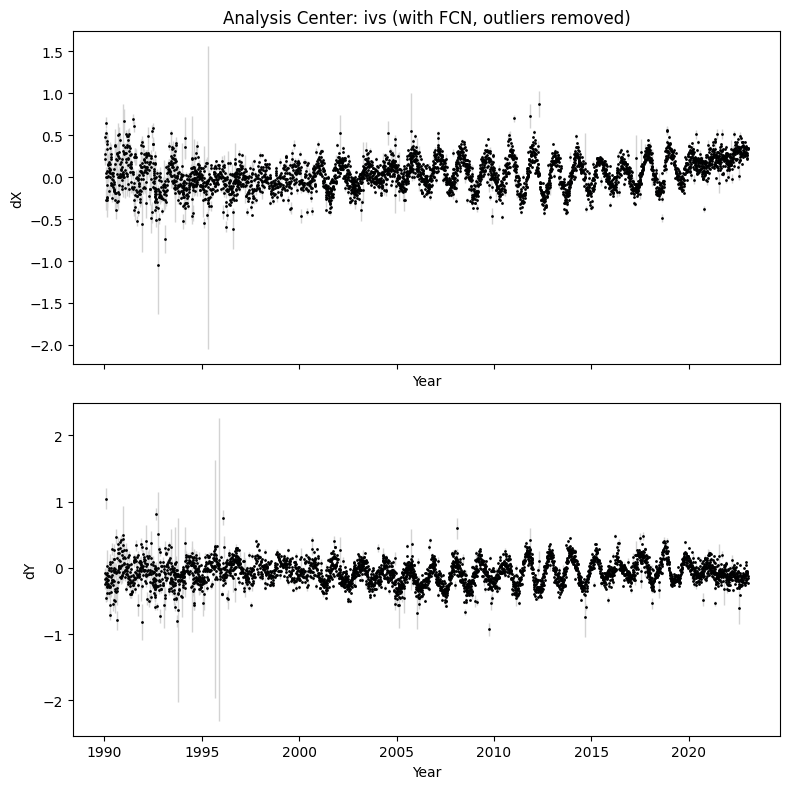

In [10]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - df_dX['MJD']) / 365.242198781, df_dX['dX'], yerr=df_dX['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: ivs (with FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - df_dY['MJD']) / 365.242198781, df_dY['dY'], yerr=df_dY['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - with FNC

In [11]:
%%time
tau_dX, allanstd_dX = allanself.oadev(df_dX['dX'].values,df_dX['MJD'].values,df_dX['sigma_dX'].values)

CPU times: total: 18min 48s
Wall time: 39min 21s


In [12]:
%%time
tau_dY, allanstd_dY = allanself.oadev(df_dY['dY'].values,df_dY['MJD'].values,df_dY['sigma_dY'].values)

CPU times: total: 18min 59s
Wall time: 31min 18s


In [13]:
ci_dX_low, ci_dX_high = allanself.confidence_int(df_dX['dX'].values,df_dX['sigma_dX'].values,allanstd_dX,modified=False,overlapping=True,devtype='allan')

In [14]:
ci_dY_low, ci_dY_high = allanself.confidence_int(df_dY['dY'].values,df_dY['sigma_dY'].values,allanstd_dY,modified=False,overlapping=True,devtype='allan')

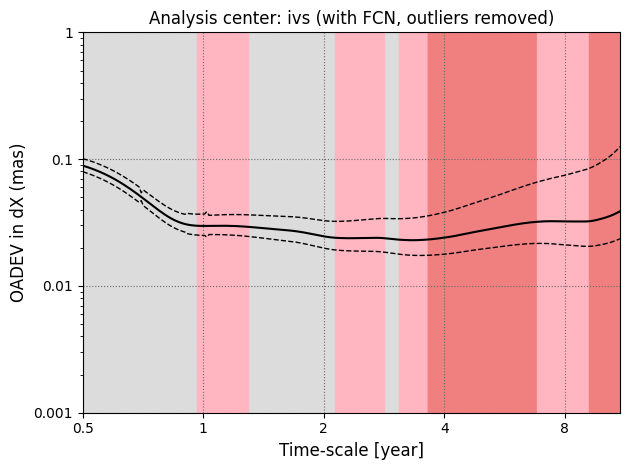

In [15]:
plt.figure()
# Calculate the slopes
slopes_dX = np.diff(np.log10(allanstd_dX)) / np.diff(np.log10(tau_dX))
tau_dX_year = [t/365.242198781 for t in tau_dX]
# Plot allanstd

plt.plot(tau_dX_year,allanstd_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_dX) & (slopes_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dX_year[1:], 0, 10**5, where= (slopes_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dX_year, ci_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dX_year, ci_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: ivs (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dX_year))
plt.tight_layout()

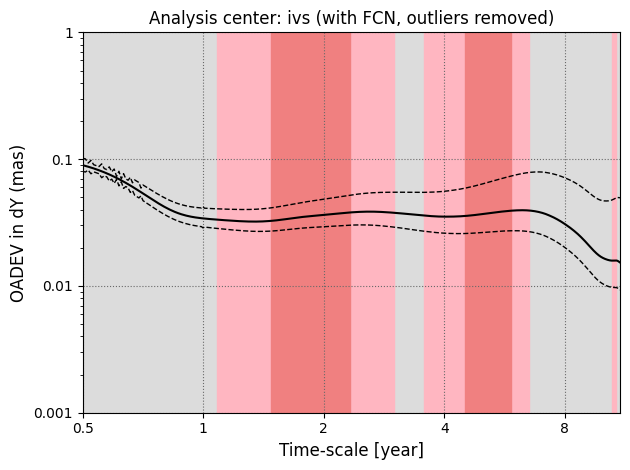

In [16]:
plt.figure()
# Calculate the slopes
slopes_dY = np.diff(np.log10(allanstd_dY)) / np.diff(np.log10(tau_dY))
tau_dY_year = [t/365.242198781 for t in tau_dY]
# Plot allanstd

plt.plot(tau_dY_year,allanstd_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_dY) & (slopes_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_dY_year[1:], 0, 10**5, where= (slopes_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
#(tau_dec_year[:-1] > 1)
# Plot confidence interval
plt.plot(tau_dY_year, ci_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_dY_year, ci_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: ivs (with FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_dY_year))
plt.tight_layout()

# Removing FCN

In [17]:
def process_fcn(fcn_txt):
    # Read data
    cols = ['MJD', 'X', 'Y', 'sigma_X', 'sigma_Y']
    cols_widths = [(0,11),(12,21),(22,31),(32,41),(42,51)]
    df = pd.read_fwf(fcn_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [18]:
fcn_ivs = process_fcn('fcn_ivs.txt')
fcn_ivs.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,45724.22,195.02,210.68,43.92,43.92
1,45764.24,277.41,63.11,43.47,43.47
2,45779.23,283.55,-0.38,43.31,43.31
3,45784.24,282.40,-21.64,43.25,43.25
4,45809.23,253.43,-122.95,42.97,42.97


In [19]:
fcn_ivs[['X','Y','sigma_X','sigma_Y']] = fcn_ivs[['X','Y','sigma_X','sigma_Y']] / 1000
fcn_ivs.head(5)

,MJD,X,Y,sigma_X,sigma_Y
0,45724.22,0.19502,0.21068,0.04392,0.04392
1,45764.24,0.27741,0.06311,0.04347,0.04347
2,45779.23,0.28355,-0.00038,0.04331,0.04331
3,45784.24,0.28240,-0.02164,0.04325,0.04325
4,45809.23,0.25343,-0.12295,0.04297,0.04297


In [20]:
df_dX.head(5)

,MJD,dX,sigma_dX
0,47904.255,0.472,0.067
1,47909.247,0.212,0.065
2,47910.344,0.275,0.075
3,47914.249,0.648,0.067
4,47919.245,0.524,0.055


In [21]:
df_dX['MJD_int'] = df_dX['MJD'].astype(int)
df_dY['MJD_int'] = df_dY['MJD'].astype(int)
fcn_ivs['MJD_int'] = fcn_ivs['MJD'].astype(int)

In [22]:
merged_dX = pd.merge(df_dX, fcn_ivs, on='MJD_int', how='inner')
merged_dX.head(5)


,MJD_x,dX,sigma_dX,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.255,0.472,0.067,47904,47904.25,0.13239,-0.05617,0.01550,0.01550
1,47909.247,0.212,0.065,47909,47909.25,0.12783,-0.06546,0.01548,0.01548
2,47910.344,0.275,0.075,47910,47910.34,0.12674,-0.06746,0.01547,0.01547
3,47914.249,0.648,0.067,47914,47914.25,0.12261,-0.07440,0.01545,0.01545
4,47919.245,0.524,0.055,47919,47919.25,0.11675,-0.08328,0.01539,0.01539


In [23]:
merged_dX = merged_dX.drop(['MJD_int', 'MJD_y','Y','sigma_Y'], axis=1)


In [24]:
merged_dX.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X
0,47904.255,0.472,0.067,0.13239,0.01550
1,47909.247,0.212,0.065,0.12783,0.01548
2,47910.344,0.275,0.075,0.12674,0.01547
3,47914.249,0.648,0.067,0.12261,0.01545
4,47919.245,0.524,0.055,0.11675,0.01539


In [25]:
merged_dX['dXnoFCN'] = merged_dX['dX'] - merged_dX['X'] 
# merged_dX['sigmanoFCN'] = abs(merged_dX['sigma_dX'] - merged_dX['sigma_X']) 
merged_dX.head(5)

,MJD,dX,sigma_dX,X,sigma_X,dXnoFCN
0,47904.255,0.472,0.067,0.13239,0.01550,0.33961
1,47909.247,0.212,0.065,0.12783,0.01548,0.08417
2,47910.344,0.275,0.075,0.12674,0.01547,0.14826
3,47914.249,0.648,0.067,0.12261,0.01545,0.52539
4,47919.245,0.524,0.055,0.11675,0.01539,0.40725


In [26]:
merged_dY = pd.merge(df_dY, fcn_ivs, on='MJD_int', how='inner')
merged_dY.head(5)


,MJD_x,dY,sigma_dY,MJD_int,MJD_y,X,Y,sigma_X,sigma_Y
0,47904.255,-0.249,0.070,47904,47904.25,0.13239,-0.05617,0.01550,0.01550
1,47909.247,-0.073,0.066,47909,47909.25,0.12783,-0.06546,0.01548,0.01548
2,47910.344,-0.174,0.111,47910,47910.34,0.12674,-0.06746,0.01547,0.01547
3,47914.249,-0.456,0.066,47914,47914.25,0.12261,-0.07440,0.01545,0.01545
4,47919.245,-0.092,0.052,47919,47919.25,0.11675,-0.08328,0.01539,0.01539


In [27]:
merged_dY = merged_dY.drop(['MJD_int', 'MJD_y','X','sigma_X'], axis=1)
merged_dY.rename(columns={'MJD_x': 'MJD'}, inplace=True)
merged_dY['dYnoFCN'] = merged_dY['dY'] - merged_dY['Y'] 
# merged_dY['sigmanoFCN'] = abs(merged_dY['sigma_dY'] - merged_dY['sigma_Y']) 
merged_dY.head(5)

,MJD,dY,sigma_dY,Y,sigma_Y,dYnoFCN
0,47904.255,-0.249,0.070,-0.05617,0.01550,-0.19283
1,47909.247,-0.073,0.066,-0.06546,0.01548,-0.00754
2,47910.344,-0.174,0.111,-0.06746,0.01547,-0.10654
3,47914.249,-0.456,0.066,-0.07440,0.01545,-0.38160
4,47919.245,-0.092,0.052,-0.08328,0.01539,-0.00872


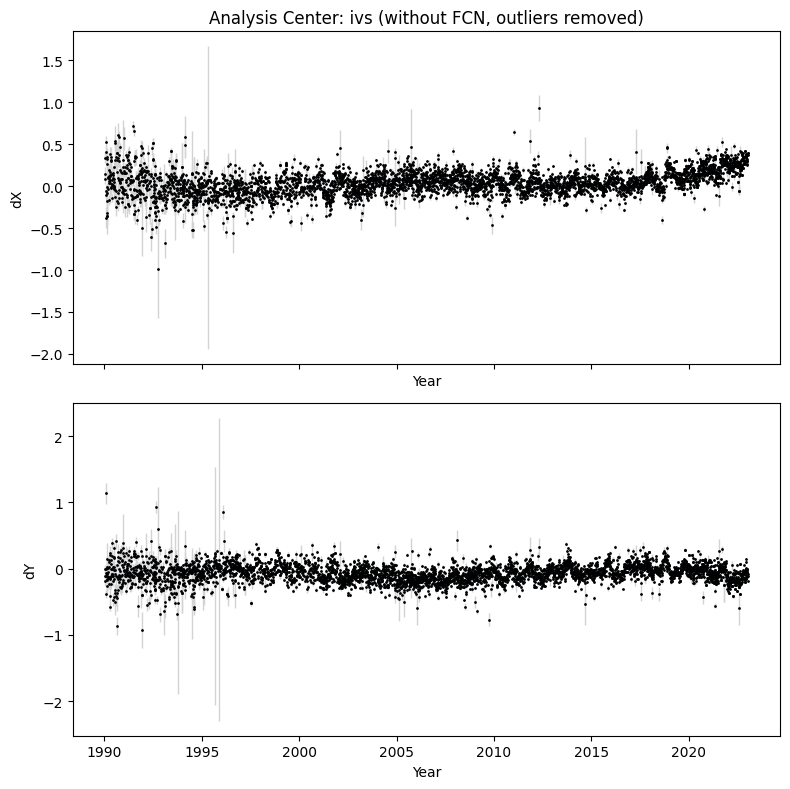

In [28]:
# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes = axes.flatten()

# Plot dX
axes[0].errorbar(2000 - (51544.333981 - merged_dX['MJD']) / 365.242198781, merged_dX['dXnoFCN'], yerr=merged_dX['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[0].set_title(f'Analysis Center: ivs (without FCN, outliers removed)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('dX')


# Plot dY
axes[1].errorbar(2000 - (51544.333981 - merged_dY['MJD']) / 365.242198781, merged_dY['dYnoFCN'], yerr=merged_dY['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 
axes[1].set_xlabel('Year')
axes[1].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan std dev - no FCN

In [29]:
%%time
tau_noFCN_dX, allanstd_noFCN_dX = allanself.oadev(merged_dX['dXnoFCN'].values,merged_dX['MJD'].values,merged_dX['sigma_dX'].values)

CPU times: total: 35min
Wall time: 37min 13s


In [30]:
%%time
tau_noFCN_dY, allanstd_noFCN_dY = allanself.oadev(merged_dY['dYnoFCN'].values,merged_dY['MJD'].values,merged_dY['sigma_dY'].values)

CPU times: total: 35min 5s
Wall time: 37min 20s


c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\Nutation\allanself.py:393: RuntimeWarning: invalid value encountered in scalar divide
  allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))


In [31]:
allanstd_noFCN_dX

array([0.04650196, 0.04177855, 0.03883409, ..., 0.02913729, 0.02919873,
       0.02926012])

In [33]:
ci_noFCN_dX_low, ci_noFCN_dX_high = allanself.confidence_int(merged_dX['dXnoFCN'].values,merged_dX['sigma_dX'].values,allanstd_noFCN_dX,modified=False,overlapping=True,devtype='allan')
ci_noFCN_dY_low, ci_noFCN_dY_high = allanself.confidence_int(merged_dY['dYnoFCN'].values,merged_dY['sigma_dY'].values,allanstd_noFCN_dY,modified=False,overlapping=True,devtype='allan')

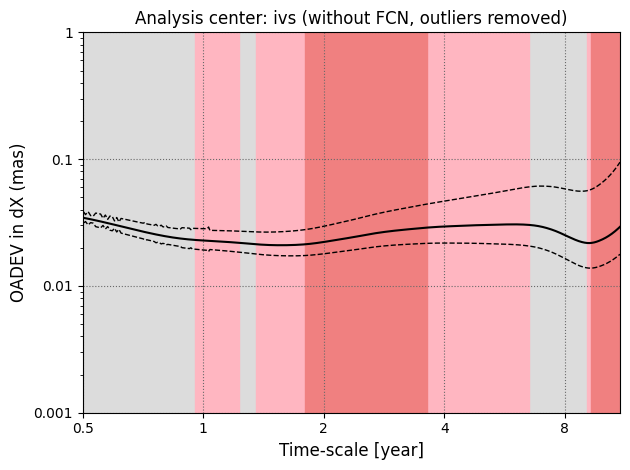

In [34]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dX = np.diff(np.log10(allanstd_noFCN_dX)) / np.diff(np.log10(tau_noFCN_dX))
tau_noFCN_dX_year = [t/365.242198781 for t in tau_noFCN_dX]
# Plot allanstd

plt.plot(tau_noFCN_dX_year,allanstd_noFCN_dX,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dX) & (slopes_noFCN_dX <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dX_year[1:], 0, 10**5, where= (slopes_noFCN_dX > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dX_year, ci_noFCN_dX_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dX (mas)', fontsize=12)
plt.title('Analysis center: ivs (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dX_year))
plt.tight_layout()

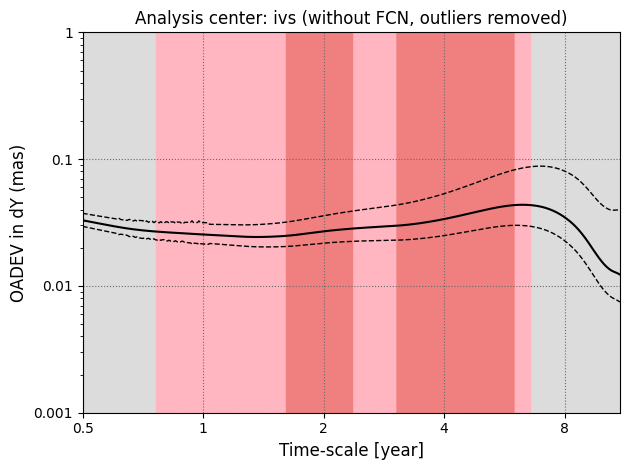

In [35]:
plt.figure()
# Calculate the slopes
slopes_noFCN_dY = np.diff(np.log10(allanstd_noFCN_dY)) / np.diff(np.log10(tau_noFCN_dY))
tau_noFCN_dY_year = [t/365.242198781 for t in tau_noFCN_dY]
# Plot allanstd

plt.plot(tau_noFCN_dY_year,allanstd_noFCN_dY,color='black',label='allanstd')
plt.grid(color='dimgray',linestyle='dotted')
# Color background according to the slopes / noise type
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY < 0.25),color='gainsboro',linewidth=1,zorder=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (-0.25 <= slopes_noFCN_dY) & (slopes_noFCN_dY <= 0.25),color='lightpink',linewidth=1)
plt.fill_between(tau_noFCN_dY_year[1:], 0, 10**5, where= (slopes_noFCN_dY > 0.25),color='lightcoral',step='mid',linewidth=1)
# Plot confidence interval
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_low,color='black',linestyle='dashed',linewidth=1)
plt.plot(tau_noFCN_dY_year, ci_noFCN_dY_high,color='black',linestyle='dashed',linewidth=1)

plt.yscale('log')
plt.xscale('log',base = 2)
plt.xlabel('Time-scale [year]', fontsize=12)
plt.ylabel(r'OADEV in dY (mas)', fontsize=12)
plt.title('Analysis center: ivs (without FCN, outliers removed)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.ylim(0.001,1)
plt.xlim(0.5,max(tau_noFCN_dY_year))
plt.tight_layout()